In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [3]:
data = pd.read_csv('../data/creditcard.csv')

In [4]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
data.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Train test and split

In [10]:
from collections import Counter
from scipy import stats
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [11]:
# Min-max normalization
numeric_features = data.dtypes[data.dtypes != 'object'].index
data[numeric_features] = data[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
data = data.fillna(0)

In [12]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
data.iloc[:, -1] = labelencoder.fit_transform(data.iloc[:, -1])
#X = data.drop([' Label'], axis=1).values
#Y = data.iloc[:, -1].values.reshape(-1,1)
#Y = np.ravel(Y)
X = data.drop('Class', axis=1)
Y = data['Class']
Y = labelencoder.fit_transform(Y)  # Ensure consistent encoding
print("Encoded classes:", labelencoder.classes_)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y)

Encoded classes: [0. 1.]


In [13]:
X_train.shape

(227845, 30)

In [14]:
Y_test.shape

(56962,)

In [15]:
pd.Series(Y_train).value_counts()

0    227451
1       394
Name: count, dtype: int64

Calculating the correlation matrix...
Correlation Matrix (preview):
          Time            V1            V2            V3            V4  \
Time  1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1    0.117396  1.000000e+00  1.746106e-14  1.027566e-13  1.486596e-14   
V2   -0.010593  1.746106e-14  1.000000e+00 -7.599107e-14 -1.710874e-14   
V3   -0.419618  1.027566e-13 -7.599107e-14  1.000000e+00  1.237002e-14   
V4   -0.105260  1.486596e-14 -1.710874e-14  1.237002e-14  1.000000e+00   

                V5            V6            V7            V8            V9  \
Time  1.730721e-01 -6.301647e-02  8.471437e-02 -3.694943e-02 -8.660434e-03   
V1    5.920763e-14  1.705832e-14 -3.063624e-14  5.470123e-15 -2.111352e-14   
V2    3.867793e-14 -5.417328e-15  1.133256e-14 -1.572443e-14 -5.282469e-15   
V3   -3.179412e-13 -9.050933e-15  5.412571e-14  3.602720e-15  2.920132e-14   
V4   -9.365645e-14  2.673617e-15  5.851469e-15 -5.392357e-16  3.331727e-15   

      ...         

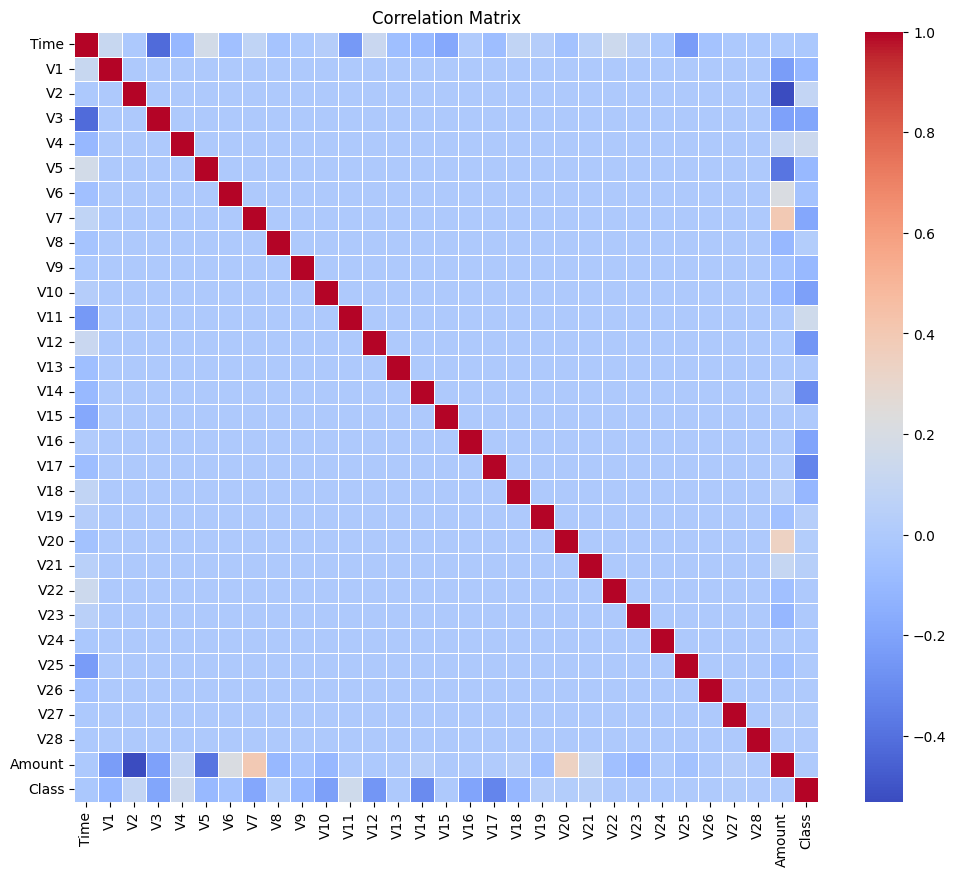

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [17]:
# # Analyze correlation with the target variable ("Class")
# if 'Class' in correlation_matrix.columns:
#     target_corr = correlation_matrix['Class'].sort_values(ascending=False)
#     print("Correlation with the target variable:")
#     print(target_corr)

#     # Visualize the strongest correlations with the target variable
#     top_features = target_corr[1:11]  # Exclude correlation with itself
#     plt.figure(figsize=(8, 6))
#     sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
#     plt.title('Top 10 Features Correlated with the Target Variable')
#     plt.xlabel('Correlation Coefficient')
#     plt.ylabel('Features')
#     plt.show()
# else:
#     print("The 'Class' column does not exist in the dataset.")

In [18]:
# # Check the range of correlation values
# max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
# min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# # Lower the threshold for moderate correlations
# threshold = 0.8  # Adjust to a lower value
# strong_corr_pairs = []

# for i in range(len(correlation_matrix.columns)):
#     for j in range(i):
#         if abs(correlation_matrix.iloc[i, j]) > threshold:
#             strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# print(f"Strongly correlated features (>|{threshold}|):")
# for pair in strong_corr_pairs:
#     print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

In [19]:
#smote = SMOTE()
print(type(Y))
print(Y.dtype)
print(np.unique(Y))
pd.Series(Y_train).value_counts()

<class 'numpy.ndarray'>
int64
[0 1]


0    227451
1       394
Name: count, dtype: int64

# Outliers removal

In [20]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest


def check_outliers(X, Y, threshold=3.0, iqr_factor=2.0):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5):
    """
    Removes outliers from normal transactions only.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Outlier removal
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Reunify data
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto")

In [ ]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=2.0)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using Z-score for outlier removal...
Outliers removed.
Cleaned Features (X):
            Time        V1        V2        V3        V4        V5        V6  \
0       0.000000  0.935192  0.766490  0.881365  0.313023  0.763439  0.267669   
1       0.000000  0.978542  0.770067  0.840298  0.271796  0.766120  0.262192   
3       0.000006  0.941878  0.765304  0.868484  0.213661  0.765647  0.275559   
4       0.000012  0.938617  0.776520  0.864251  0.269796  0.762975  0.263984   
5       0.000012  0.951057  0.777393  0.857187  0.244472  0.768550  0.262721   
...          ...       ...       ...       ...       ...       ...       ...   
284800  0.999954  0.992943  0.765409  0.816674  0.262329  0.765658  0.255715   
284801  0.999959  0.960338  0.777082  0.827952  0.218901  0.773326  0.260647   
284803  0.999971  0.945845  0.766677  0.872678  0.219189  0.771561  0.273661   
284804  0.999977  0.990905  0.764080  0.781102  0

In [22]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Oversampling using ROS

In [23]:
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
# Apply Random Oversampling
ros = RandomOverSampler(sampling_strategy=0.8, random_state=42)
X_resampled, Y_resampled = ros.fit_resample(X_train, y_train)
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(Y_resampled, name='Class')], axis=1)

# Display the class distribution after ROS
class_distribution_after = Counter(data_resampled['Class'])
print("Class Distribution After ROS:", class_distribution_after)

Class Distribution After ROS: Counter({0: 195318, 1: 156254})


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y_resampled)

In [25]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Calculate the correlation matrix
# print("Calculating the correlation matrix...")
# correlation_matrix = data_resampled.corr()

# # Display the first few rows of the correlation matrix
# print("Correlation Matrix (preview):")
# print(correlation_matrix.head())

# # Visualize the correlation matrix with a heatmap
# plt.figure(figsize=(12, 10))
# sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

In [26]:
# # Analyze correlation with the target variable ("Class")
# if 'Class' in correlation_matrix.columns:
#     target_corr = correlation_matrix['Class'].sort_values(ascending=False)
#     print("Correlation with the target variable:")
#     print(target_corr)

#     # Visualize the strongest correlations with the target variable
#     top_features = target_corr[1:11]  # Exclude correlation with itself
#     plt.figure(figsize=(8, 6))
#     sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
#     plt.title('Top 10 Features Correlated with the Target Variable')
#     plt.xlabel('Correlation Coefficient')
#     plt.ylabel('Features')
#     plt.show()
# else:
#     print("The 'Class' column does not exist in the dataset.")

In [27]:
# # Check the range of correlation values
# max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
# min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# # Check for NaN values in the correlation matrix
# #print("Number of NaN values in the correlation matrix:", correlation_matrix.isna().sum().sum())

# # Lower the threshold for moderate correlations
# threshold = 0.8  # Adjust to a lower value
# strong_corr_pairs = []

# for i in range(len(correlation_matrix.columns)):
#     for j in range(i):
#         if abs(correlation_matrix.iloc[i, j]) > threshold:
#             strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# print(f"Strongly correlated features (>|{threshold}|):")
# for pair in strong_corr_pairs:
#     print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

# Feature importance

In [28]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


In [29]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50)
}

In [30]:
feature_importances = np.zeros(X_resampled.shape[1])
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,Y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[9.32742372e-03 4.27638953e-03 1.65391337e-02 4.25255639e-03
 6.69170430e-02 1.04193240e-02 1.47541724e-03 2.78092062e-02
 2.76994655e-02 3.43685834e-03 1.88987834e-02 3.13557585e-03
 1.62887673e-02 1.64441273e-02 7.15448183e-01 1.99046058e-04
 1.95039196e-04 1.27342608e-02 6.74539203e-03 9.26396580e-05
 9.25426029e-03 1.92966591e-04 0.00000000e+00 1.18568451e-03
 3.74552686e-03 2.96026608e-03 1.40190567e-02 3.58131375e-03
 1.16319014e-03 1.56310320e-03]
Random Forest Feature Importances:
[0.00519807 0.01155571 0.04160876 0.06962142 0.10177911 0.0054983
 0.00439617 0.01855682 0.01125938 0.02255696 0.1183101  0.0455455
 0.10008724 0.00682789 0.19390733 0.00599969 0.04706501 0.08499448
 0.01002206 0.01145531 0.01406489 0.01776061 0.00474888 0.00650343
 0.00390263 0.00453803 0.00814152 0.01139964 0.00431621 0.00837883]
Extra Trees Feature Importances:
[0.00864375 0.02193203 0.01829755 0.07189518 0.087532   0.01331284
 0.01897059 0.04475268 0.01211198 0.0

In [31]:
print(len(models))

5


In [32]:
avg_feature = feature_importances/len(models)

In [33]:
feature=(data.drop(['Class'],axis=1)).columns.values
print ("Features sorted by their score:")
sorted_features = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)
sorted_scores, sorted_names = zip(*sorted_features)
cumulative_importance = np.cumsum(sorted_scores)

index = np.where(cumulative_importance >= 0.9)[0][0]
important_features = sorted_names[:index+1]
# Ensure important_features contains the actual column names
important_features = list(important_features)

# Select only the columns corresponding to the important features
X_selected = X_resampled[important_features].values
print(important_features)
print(X_resampled.columns)

Features sorted by their score:
['V14', 'V4', 'V12', 'V10', 'V3', 'V17', 'V8', 'V11', 'V7', 'V20', 'V16', 'V19', 'V18', 'V2', 'V1', 'V9', 'V21']
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')


In [34]:
len(sorted_features)

30

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=Y_resampled)

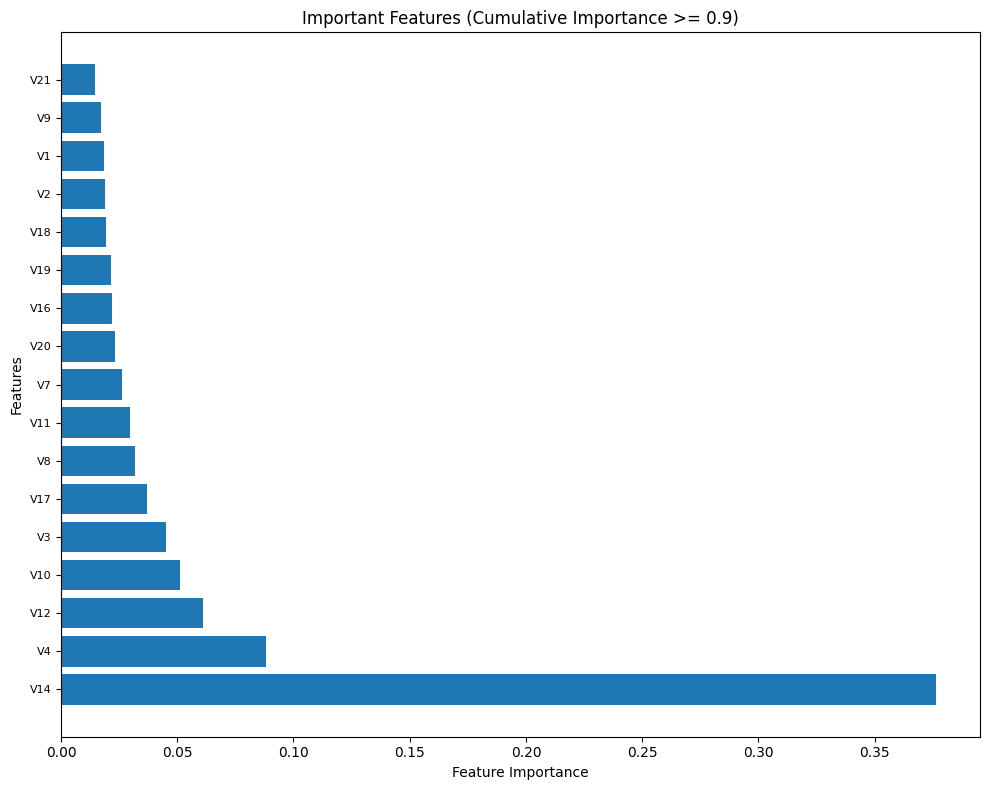

╒═══════════╤═══════════╕
│ Feature   │    Weight │
╞═══════════╪═══════════╡
│ V14       │ 0.417545  │
├───────────┼───────────┤
│ V4        │ 0.0975934 │
├───────────┼───────────┤
│ V12       │ 0.0678718 │
├───────────┼───────────┤
│ V10       │ 0.0567816 │
├───────────┼───────────┤
│ V3        │ 0.0500166 │
├───────────┼───────────┤
│ V17       │ 0.0409227 │
├───────────┼───────────┤
│ V8        │ 0.0354885 │
├───────────┼───────────┤
│ V11       │ 0.032716  │
├───────────┼───────────┤
│ V7        │ 0.0291671 │
├───────────┼───────────┤
│ V20       │ 0.0256183 │
├───────────┼───────────┤
│ V16       │ 0.0243984 │
├───────────┼───────────┤
│ V19       │ 0.023622  │
├───────────┼───────────┤
│ V18       │ 0.0212931 │
├───────────┼───────────┤
│ V2        │ 0.0208495 │
├───────────┼───────────┤
│ V1        │ 0.0205168 │
├───────────┼───────────┤
│ V9        │ 0.019186  │
├───────────┼───────────┤
│ V21       │ 0.0164134 │
╘═══════════╧═══════════╛


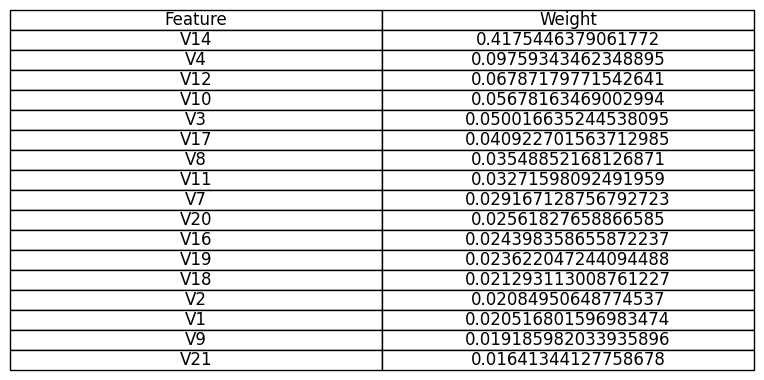

In [36]:
from tabulate import tabulate
# Step 10: Visualize the selected features
plt.figure(figsize=(10, 8))
plt.barh(range(len(important_features)), sorted_scores[:index+1], align='center')
plt.yticks(range(len(important_features)), important_features, fontsize=8)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title('Important Features (Cumulative Importance >= 0.9)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 11: Display the selected features and their weights in a table
important_scores = sorted_scores[:index+1]
total_importance = np.sum(important_scores)
weights = important_scores / total_importance

table_data = [[feature, weight] for feature, weight in zip(important_features, weights)]
headers = ["Feature", "Weight"]

# Print the table
table_str = tabulate(table_data, headers, tablefmt="fancy_grid")
print(table_str)

# Save the table as a PDF
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig("feature_importance_table.pdf", bbox_inches="tight")

# GridSearch application

In [37]:
from sklearn.model_selection import GridSearchCV
# Define Parameter Grids for GridSearchCV
param_grid_dt = {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_et = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}

In [38]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

# Train and Tune Models
def grid_search(model, param_grid, name):
    grid = GridSearchCV(model, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_


best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 2}


In [39]:
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")

Best parameters for Random Forest: {'max_depth': 20, 'n_estimators': 100}


In [40]:
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")

Best parameters for Extra Trees: {'max_depth': None, 'n_estimators': 200}


In [41]:
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")

Best parameters for XGBoost: {'learning_rate': 0.2, 'n_estimators': 200}


In [42]:
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50), param_grid_ada, "AdaBoost")

Best parameters for AdaBoost: {'learning_rate': 1, 'n_estimators': 200}


In [43]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
import numpy as np
from typing import List, Tuple, Dict, Any

import warnings, multiprocessing.util

# Hide the resource_tracker warnings (safe)
warnings.filterwarnings("ignore", category=UserWarning, module='multiprocessing.resource_tracker')

# Prevent resource_tracker from throwing ChildProcessError at shutdown
multiprocessing.util.log_to_stderr = lambda *a, **kw: None

def create_meta_features(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    base_models: List[Tuple[str, Any]],
    n_splits: int = 5,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create meta-features using cross-validation predictions from base models.
    
    Args:
        X_train: Training features
        X_test: Test features
        y_train: Training labels
        base_models: List of tuples containing (name, model) pairs
        n_splits: Number of cross-validation splits
        random_state: Random seed for reproducibility
        
    Returns:
        Tuple containing meta-features for training and test sets
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    n_models = len(base_models)
    meta_features_train = np.zeros((X_train.shape[0], n_models))
    meta_features_test = np.zeros((X_test.shape[0], n_models))
    
    # Generate meta-features through cross-validation
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr = y_train[train_idx]
        
        # Train base models and store predictions for meta-model
        for i, (_, model) in enumerate(base_models):
            model.fit(X_tr, y_tr)
            meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]
    
    # Fit final models on full training data to predict test meta-features
    for i, (_, model) in enumerate(base_models):
        model.fit(X_train, y_train)
        meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]
        
    return meta_features_train, meta_features_test


def optimize_voting_classifier(
    meta_features_train: np.ndarray,
    y_train: np.ndarray,
    base_models: List[Tuple[str, Any]],
    param_grid: Dict[str, List[Any]] = None,
    cv: int = 5
) -> Tuple[VotingClassifier, Dict[str, Any]]:
    """
    Optimize a voting classifier using grid search.
    
    Args:
        meta_features_train: Meta-features for training
        y_train: Training labels
        base_models: List of tuples containing (name, model) pairs
        param_grid: Parameter grid for GridSearchCV
        cv: Number of cross-validation folds
        
    Returns:
        Tuple containing the best voting classifier and the best parameters
    """
    voting_clf = VotingClassifier(estimators=base_models, voting='soft')
    
    if param_grid is None:
        param_grid = {
            'weights': [
                (1, 1, 1, 1, 1),
                (1, 2, 2, 3, 1),
                (2, 1, 1, 1, 2),
                (3, 2, 1, 2, 1),
                (1, 1, 2, 2, 3)
            ]
        }
    
    grid_voting = GridSearchCV(
        voting_clf, 
        param_grid, 
        cv=cv, 
        scoring='accuracy', 
        n_jobs=-1
    )
    grid_voting.fit(meta_features_train, y_train)
    
    return grid_voting.best_estimator_, grid_voting.best_params_


# Define base models
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]

# Ensure y_train is a numpy array
y_train = np.array(y_train)

# Create meta-features
meta_features_train, meta_features_test = create_meta_features(
    X_train, X_test, y_train, base_models
)

# Optimize voting classifier
best_voting, best_params = optimize_voting_classifier(
    meta_features_train, y_train, base_models
)

print(f"Best Voting Weights: {best_params}")

Best Voting Weights: {'weights': (1, 1, 1, 1, 1)}


# Second Stage : LSTM predictions

In [44]:
# Step 3: LSTM Meta-Learner on top of Voting Classifier Predictions

best_voting.fit(X_train, y_train)

,estimators,"[('dt', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,"(1, ...)"
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [45]:

# -----------------------------------------------------------
# 1. Get Predictions (probabilities) from the Voting Classifier
# -----------------------------------------------------------
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probability of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]    # Probability of class 1

# -----------------------------------------------------------
# 2. Reshape Predictions for LSTM input
#    LSTM expects input shape = (samples, timesteps, features)
# -----------------------------------------------------------
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # (n_samples, 1 timestep, 1 feature)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)    # (n_samples, 1 timestep, 1 feature)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")


X_train_lstm shape: (281257, 1, 1)
X_test_lstm shape: (70315, 1, 1)


In [46]:
import tensorflow as tf
from keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.15.0
GPU available: True


In [47]:

def convert_labels_to_categorical(y_train, y_test, num_classes=2):
    """
    Convert integer class labels to categorical one-hot encoding format.
    
    Args:
        y_train (numpy.ndarray): Training labels as integers.
        y_test (numpy.ndarray): Testing labels as integers.
        num_classes (int, optional): Number of classes in the dataset. Defaults to 2.
        
    Returns:
        tuple: A tuple containing (y_train_categorical, y_test_categorical)
    """
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    y_test_cat = to_categorical(y_test, num_classes=num_classes)
    
    # Print shape information for verification
    print(f"Shape of y_train_cat: {y_train_cat.shape}")
    print(f"Shape of y_test_cat: {y_test_cat.shape}")
    
    return y_train_cat, y_test_cat

# Convert labels to categorical format
y_train_cat, y_test_cat = convert_labels_to_categorical(y_train, y_test)

Shape of y_train_cat: (281257, 2)
Shape of y_test_cat: (70315, 2)


# Final performance results

# Add autoencoders

In [50]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score
import time

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
start_train = time.time()

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm))

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)


Epoch 1/50
8790/8790 [==============================] - 61s 7ms/step - loss: 0.0012 - val_loss: 5.7273e-05
Epoch 2/50
8790/8790 [==============================] - 57s 7ms/step - loss: 0.0010 - val_loss: 2.1754e-04
Epoch 3/50
8790/8790 [==============================] - 60s 7ms/step - loss: 0.0010 - val_loss: 2.4204e-04
Epoch 4/50
8790/8790 [==============================] - 60s 7ms/step - loss: 0.0010 - val_loss: 1.4117e-04
Epoch 5/50
8790/8790 [==============================] - 61s 7ms/step - loss: 9.9678e-04 - val_loss: 2.2096e-04
Epoch 6/50
8790/8790 [==============================] - 59s 7ms/step - loss: 9.5314e-04 - val_loss: 3.0477e-04
Epoch 7/50
8790/8790 [==============================] - 60s 7ms/step - loss: 9.2251e-04 - val_loss: 2.5589e-04
Epoch 8/50
8790/8790 [==============================] - 60s 7ms/step - loss: 8.3351e-04 - val_loss: 5.9590e-04
Epoch 9/50
8790/8790 [==============================] - 60s 7ms/step - loss: 8.2607e-04 - val_loss: 7.1709e-04
Epoch 10/50
8790/

In [51]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]
#print("X_train_encoded shape:", X_train_encoded.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_encoded shape:", X_test_encoded.shape)
# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import Recall
from tensorflow.keras.regularizers import l2
from typing import Tuple, List, Optional


def create_reduce_lr_callback(
    monitor: str = 'val_loss',
    factor: float = 0.5,
    patience: int = 3,
    min_lr: float = 1e-6
) -> ReduceLROnPlateau:
    """
    Creates a ReduceLROnPlateau callback for learning rate adjustment during training.
    
    Args:
        monitor: Metric to monitor for improvement
        factor: Factor by which to reduce learning rate
        patience: Number of epochs with no improvement after which LR will be reduced
        min_lr: Lower bound on the learning rate
        
    Returns:
        ReduceLROnPlateau callback configured with the specified parameters
    """
    return ReduceLROnPlateau(
        monitor=monitor,
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )


def create_lstm_model(
    l2_reg: float = 0.001,
    dropout_rate: float = 0.3,
    num_classes: int = 2
) -> Sequential:
    """
    Creates an LSTM model for sequence classification.
    
    Args:
        l2_reg: L2 regularization factor
        dropout_rate: Dropout rate for regularization
        num_classes: Number of output classes
        
    Returns:
        Compiled Keras Sequential LSTM model
    """
    model = Sequential([
        LSTM(64, return_sequences=False, kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax', kernel_regularizer=l2(l2_reg))
    ])
    
    # Configure optimizer with weight decay
    optimizer = AdamW(
        learning_rate=0.001,
        weight_decay=1e-4,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7
    )
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', Recall()]
    )
    
    return model


# Create the learning rate reduction callback
reduce_lr = create_reduce_lr_callback()

# Create and compile the LSTM model
lstm_model = create_lstm_model()

# Train the model
history = lstm_model.fit(
    X_train_lstm_ae,
    y_train_cat,
    epochs=30,
    batch_size=17,
    validation_data=(X_test_lstm_ae, y_test_cat),
    callbacks=[reduce_lr]
)
end_train = time.time()
training_time = end_train - start_train

Epoch 1/30
16545/16545 [==============================] - 260s 16ms/step - loss: 0.0052 - accuracy: 0.9989 - recall: 0.9989 - val_loss: 8.7336e-04 - val_accuracy: 1.0000 - val_recall: 1.0000 - lr: 0.0010
Epoch 2/30
16545/16545 [==============================] - 257s 16ms/step - loss: 5.5102e-04 - accuracy: 1.0000 - recall: 1.0000 - val_loss: 4.1533e-04 - val_accuracy: 1.0000 - val_recall: 1.0000 - lr: 0.0010
Epoch 3/30
16545/16545 [==============================] - 256s 15ms/step - loss: 4.4320e-04 - accuracy: 1.0000 - recall: 1.0000 - val_loss: 3.2877e-04 - val_accuracy: 1.0000 - val_recall: 1.0000 - lr: 0.0010
Epoch 4/30
16545/16545 [==============================] - 250s 15ms/step - loss: 5.3028e-04 - accuracy: 1.0000 - recall: 1.0000 - val_loss: 3.7488e-04 - val_accuracy: 1.0000 - val_recall: 1.0000 - lr: 0.0010
Epoch 5/30
16545/16545 [==============================] - 251s 15ms/step - loss: 5.0006e-04 - accuracy: 1.0000 - recall: 1.0000 - val_loss: 4.1639e-04 - val_accuracy: 1.000

In [53]:
# Step 5: Evaluate LSTM Meta-Learner


start_infer = time.time()
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)
#accuracy_raw = accuracy_score(y_test, np.argmax(y_pred_lstm_raw, axis=1))

end_infer = time.time()
inference_time = end_infer - start_infer

y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)

2198/2198 [==============================] - 4s 2ms/step


In [54]:
# Latency and throughput
n_samples = len(X_test_lstm_ae)
latency_ms = (inference_time / n_samples) * 1000
throughput = n_samples / inference_time

In [55]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_squared_error,roc_auc_score,roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef

In [ ]:
lstm_model_raw = create_lstm_model()

start_train_raw = time.time()

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat), callbacks=[reduce_lr])
end_train_raw = time.time()
training_time_raw = end_train_raw - start_train_raw

Epoch 1/30
 6728/16545 [===========>..................] - ETA: 2:15 - loss: 0.0060 - accuracy: 1.0000 - recall_2: 1.0000   

In [ ]:
start_infer_raw = time.time()
y_pred_lstm_raw = lstm_model_raw.predict(X_test_lstm)
#accuracy_raw = accuracy_score(y_test, np.argmax(y_pred_lstm_raw, axis=1))

end_infer_raw = time.time()
inference_time_raw = end_infer_raw - start_infer_raw
y_pred_lstm_labels = np.argmax(y_pred_lstm_raw, axis=1)

# Calculate accuracy of LSTM Meta-Learner
#final_accuracy = accuracy_score(y_test, y_pred_lstm_ae_labels)
#print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

In [ ]:
# Latency and throughput
n_samples_raw = len(X_test_lstm)
latency_ms_raw = (inference_time / n_samples) * 1000
throughput_raw = n_samples / inference_time

In [ ]:
print("\n📊 Performance without Autoencoder (LSTM):\n")
print(f"Training Time (s): {training_time_raw:.4f}")
print(f"Inference Time (s): {inference_time_raw:.4f}")
print(f"Latency (ms/sample): {latency_ms_raw:.4f}")
print(f"Throughput (samples/s): {throughput_raw:.2f}")

# =============================
# 4. Classification Metrics
# =============================
print("\nClassification report:")
print(classification_report(y_test, y_pred_lstm_labels))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lstm_labels))

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Precision:", precision_score(y_test, y_pred_lstm_labels))
print("Recall:", recall_score(y_test, y_pred_lstm_labels))
print("F1-Score:", f1_score(y_test, y_pred_lstm_labels))

# F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score:", f2)

print("Cohen's Kappa Score:", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC):", matthews_corrcoef(y_test, y_pred_lstm_labels))

# =============================
# 5. Confusion-Matrix Derived Metrics
# =============================
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_labels).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
g_means = np.sqrt(sensitivity * specificity)

print(f"Specificity: {specificity:.4f}")
print(f"G-Means: {g_means:.4f}")

# =============================
# 6. ROC & AUC
# =============================
auc_score = roc_auc_score(y_test, y_pred_lstm)
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})", linewidth=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM (Without Autoencoder)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Performance with Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lstm_ae_labels))

print(f"Training Time (s): {training_time:.4f}")
print(f"Inference Time (s): {inference_time:.4f}")
print(f"Latency (ms/sample): {latency:.4f}")
print(f"Throughput (samples/s): {throughput:.4f}")

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))

# Confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Sensitivity (Recall)
sensitivity = tp / (tp + fn)

# Specificity
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")

# G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")

# AUC
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)
print(f"AUC-ROC : {auc_score}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Sauvegarde du modèle avec pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(lstm_model, f)

In [ ]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

In [ ]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
train_recall1 = history.history['recall']
val_recall1 = history.history['val_recall']

train_recall2 = history_raw.history['recall_1']
val_recall2 = history_raw.history['val_recall_1']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='With Autoencoder - Training Racall', color='blue')
plt.plot(val_recall1, label='With Autoencoder - Validation Recall', color='orange')

plt.plot(train_recall2, label='Without Autoencoder - Training Recall', color='green')
plt.plot(val_recall2, label='Without Autoencoder - Validation Recall', color='red')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Accuracy and Recall over epochs
train_acc = history.history['accuracy']          # training accuracy per epoch
val_acc   = history.history['val_accuracy']      # validation accuracy per epoch

train_acc_raw = history_raw.history['accuracy']          # training accuracy per epoch
val_acc_raw   = history_raw.history['val_accuracy']      # validation accuracy per epoch


train_recall = history.history['recall']
val_recall = history.history['val_recall']

train_recall_raw = history_raw.history['recall_1']
val_recall_raw = history_raw.history['val_recall_1']


# Convert to numpy arrays
train_acc = np.array(train_acc)
val_acc   = np.array(val_acc)
train_acc_raw = np.array(train_acc_raw)
val_acc_raw   = np.array(val_acc_raw)

train_recall = np.array(train_recall)
val_recall   = np.array(val_recall)
train_recall_raw = np.array(train_recall_raw)
val_recall_raw   = np.array(val_recall_raw)

train_loss = np.array(history.history['loss'])
val_loss   = np.array(history.history['val_loss'])
train_loss2 = np.array(history_raw.history['loss'])
val_loss2   = np.array(history_raw.history['val_loss'])

# Compute generalization gaps
acc_gap = train_acc - val_acc
acc_gap_raw = train_acc_raw - val_acc_raw

recall_gap = train_recall - val_recall
recall_gap_raw = train_recall_raw - val_recall_raw

loss_gap = val_loss - train_loss
loss_gap_raw = val_loss2 - train_loss2

# Identify overfitting epochs
overfit_loss_epochs = np.where(loss_gap > 0)[0]
overfit_loss_epochs_raw = np.where(loss_gap_raw > 0)[0]

overfit_acc_epochs = np.where(acc_gap > 0)[0]
overfit_acc_epochs_raw = np.where(acc_gap_raw > 0)[0]

overfit_recall_epochs = np.where(recall_gap > 0)[0]
overfit_recall_epochs_raw = np.where(recall_gap_raw > 0)[0]

import matplotlib.pyplot as plt

# --- Accuracy Gap ---
plt.figure(figsize=(6,5))
plt.plot(acc_gap, label='SV2LSTM Accuracy Gap', color='blue', linestyle='-')
plt.plot(acc_gap_raw, label='SV2LSTM+AE Accuracy Gap', color='orange', linestyle='--')
plt.scatter(overfit_acc_epochs, acc_gap[overfit_acc_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_acc_epochs_raw, acc_gap_raw[overfit_acc_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Accuracy')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.savefig("SV2LSTM_Accuracy_Gap.png", dpi=300)
plt.close()

# --- Recall Gap ---
plt.figure(figsize=(6,5))
plt.plot(recall_gap, label='SV2LSTM Recall Gap', color='blue', linestyle='-')
plt.plot(recall_gap_raw, label='SV2LSTM+AE Recall Gap', color='orange', linestyle='--')
plt.scatter(overfit_recall_epochs, recall_gap[overfit_recall_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_recall_epochs_raw, recall_gap_raw[overfit_recall_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Recall')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Recall')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.savefig("SV2LSTM_Recall_Gap.png", dpi=300)
plt.close()

# --- Loss Gap ---
plt.figure(figsize=(6,5))
plt.plot(loss_gap, label='SV2LSTM Loss Gap', color='blue')
plt.plot(loss_gap_raw, label='SV2LSTM+AE Loss Gap', color='orange', linestyle='--')
plt.scatter(overfit_loss_epochs, loss_gap[overfit_loss_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_loss_epochs_raw, loss_gap_raw[overfit_loss_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.savefig("SV2LSTM_Loss_Gap.png", dpi=300)
plt.close()

# --- Combined Figure ---
plt.figure(figsize=(18,5))

# Accuracy
plt.subplot(1,3,1)
plt.plot(acc_gap, label='SV2LSTM Accuracy Gap', color='blue', linestyle='-')
plt.plot(acc_gap_raw, label='SV2LSTM+AE Accuracy Gap', color='orange', linestyle='--')
plt.scatter(overfit_acc_epochs, acc_gap[overfit_acc_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_acc_epochs_raw, acc_gap_raw[overfit_acc_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Accuracy')
plt.grid(False)
plt.legend()

# Recall
plt.subplot(1,3,2)
plt.plot(recall_gap, label='SV2LSTM Recall Gap', color='blue', linestyle='-')
plt.plot(recall_gap_raw, label='SV2LSTM+AE Recall Gap', color='orange', linestyle='--')
plt.scatter(overfit_recall_epochs, recall_gap[overfit_recall_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_recall_epochs_raw, recall_gap_raw[overfit_recall_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Recall')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Recall')
plt.grid(False)
plt.legend()

# Loss
plt.subplot(1,3,3)
plt.plot(loss_gap, label='SV2LSTM Loss Gap', color='blue')
plt.plot(loss_gap_raw, label='SV2LSTM+AE Loss Gap', color='orange', linestyle='--')
plt.scatter(overfit_loss_epochs, loss_gap[overfit_loss_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_loss_epochs_raw, loss_gap_raw[overfit_loss_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.savefig("SV2LSTM_CCFD2013_ROS_generalization_gap_combined.png", dpi=300)
plt.show()


# Optional: print first overfitting epoch for each metric
if len(overfit_loss_epochs) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM): {overfit_loss_epochs[0]+1}")
if len(overfit_loss_epochs_raw) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM+AE): {overfit_loss_epochs_raw[0]+1}")
if len(overfit_acc_epochs) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM): {overfit_acc_epochs[0]+1}")
if len(overfit_acc_epochs_raw) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM+AE): {overfit_acc_epochs_raw[0]+1}")
if len(overfit_recall_epochs) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM): {overfit_recall_epochs[0]+1}")
if len(overfit_recall_epochs_raw) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM+AE): {overfit_recall_epochs_raw[0]+1}")
